<a href="https://colab.research.google.com/github/enikulchev/EN/blob/main/ND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Константа C = 0.243167
Среднее tilde_J1 * J2 = 0.243167
Стд. отклонение = 4.807407e-17


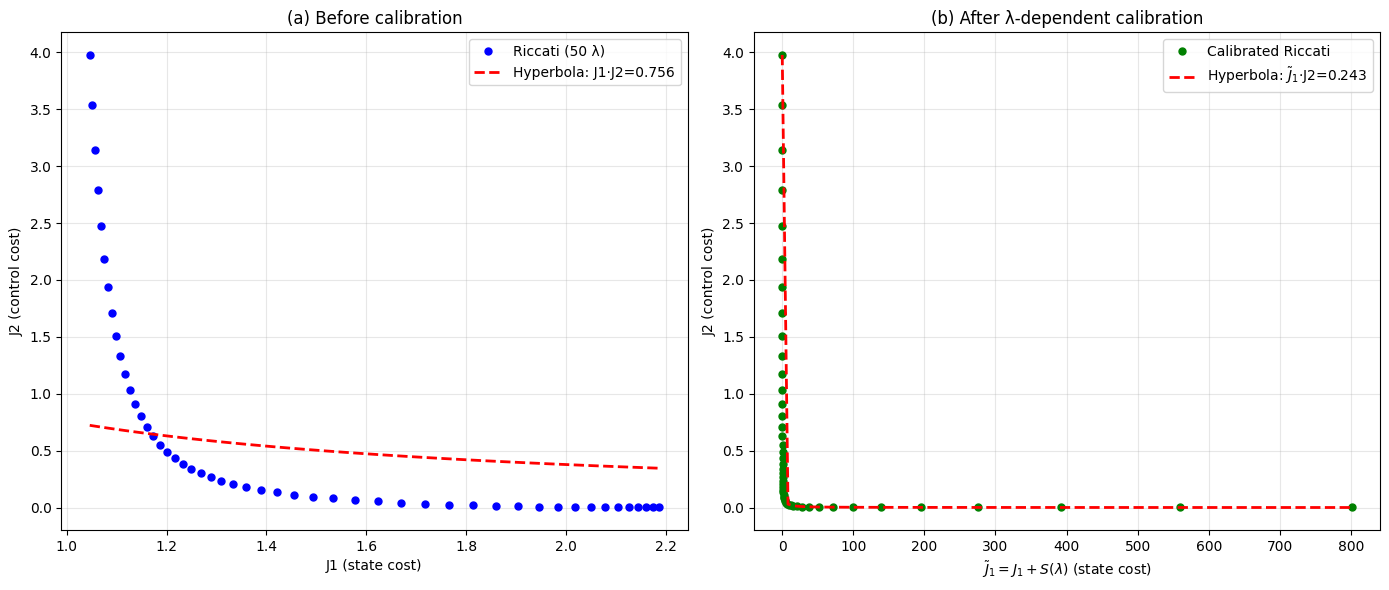


=== Данные для таблицы ===
λ          J1           J2           J1*J2        S(λ)         tilde_J1     tilde_J1*J2 
----------------------------------------------------------------------------------------------------
1.00e-02  1.0459    3.9781    4.1608    -0.9848    0.0611    0.2432
2.56e-02  1.0748    2.1876    2.3512    -0.9636    0.1112    0.2432
6.55e-02  1.1163    1.1743    1.3109    -0.9092    0.2071    0.2432
1.68e-01  1.1733    0.6259    0.7344    -0.7848    0.3885    0.2432
4.29e-01  1.2495    0.3394    0.4241    -0.5330    0.7165    0.2432
1.10e+00  1.3597    0.1788    0.2432    0.0000    1.3597    0.2432
2.81e+00  1.5338    0.0796    0.1220    1.5227    3.0565    0.2432
7.20e+00  1.7667    0.0264    0.0467    7.4294    9.1961    0.2432
1.84e+01  1.9843    0.0065    0.0128    35.7086    37.6928    0.2432
4.71e+01  2.1257    0.0012    0.0027    192.7800    194.9057    0.2432
1.00e+02  2.1867    0.0003    0.0007    798.6588    800.8455    0.2432


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import solve_continuous_are
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Система и параметры
# ------------------------------------------------------------
A = np.array([[0., 1.], [-1., -0.5]])
B = np.array([[0.], [1.]])
Q = np.eye(2)
R = np.array([[1.0]])
x0 = np.array([1., 0.])

def compute_lqr_criteria(lam, A, B, Q, R, x0, t_span=(0, 50), n_points=1000):
    R_lam = lam * R
    P = solve_continuous_are(A, B, Q, R_lam)
    K = np.linalg.solve(R_lam, B.T @ P)
    Acl = A - B @ K
    t_eval = np.linspace(t_span[0], t_span[1], n_points)
    def sys(t, x):
        return Acl @ x
    sol = solve_ivp(sys, t_span, x0, t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
    x_t = sol.y.T
    t = sol.t
    J1 = 0.0
    J2 = 0.0
    for i in range(len(t)-1):
        dt = t[i+1] - t[i]
        x_mid = 0.5 * (x_t[i] + x_t[i+1])
        u = -K @ x_mid
        J1 += x_mid.T @ Q @ x_mid * dt
        J2 += u.T @ R @ u * dt
    return J1, J2, P, K

lambda_vals = np.logspace(-2, 2, 50)
J1_list = []
J2_list = []

for lam in lambda_vals:
    J1, J2, _, _ = compute_lqr_criteria(lam, A, B, Q, R, x0)
    if np.isfinite(J1):
        J1_list.append(J1)
        J2_list.append(J2)

J1_arr = np.array(J1_list)
J2_arr = np.array(J2_list)

# ------------------------------------------------------------
# 2. Калибровка: S(λ) = C/J2 - J1
# ------------------------------------------------------------
# Выбираем C как среднее J1*J2 (можно взять любое значение, например, при λ=1)
C = J1_arr[25] * J2_arr[25]  # значение при λ ≈ 1
S_lambda = C / J2_arr - J1_arr

# Скорректированные значения J1
tilde_J1 = J1_arr + S_lambda
tilde_prod = tilde_J1 * J2_arr

print(f"Константа C = {C:.6f}")
print(f"Среднее tilde_J1 * J2 = {np.mean(tilde_prod):.6f}")
print(f"Стд. отклонение = {np.std(tilde_prod):.6e}")

# ------------------------------------------------------------
# 3. График
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# До калибровки
ax1.plot(J1_arr, J2_arr, 'bo', markersize=5, label='Riccati (50 λ)')
mean_prod = np.mean(J1_arr * J2_arr)
J1_hyper = np.linspace(min(J1_arr), max(J1_arr), 100)
J2_hyper = mean_prod / J1_hyper
ax1.plot(J1_hyper, J2_hyper, 'r--', linewidth=2, label=f'Hyperbola: J1·J2={mean_prod:.3f}')
ax1.set_xlabel('J1 (state cost)')
ax1.set_ylabel('J2 (control cost)')
ax1.set_title('(a) Before calibration')
ax1.legend()
ax1.grid(True, alpha=0.3)

# После калибровки
ax2.plot(tilde_J1, J2_arr, 'go', markersize=5, label='Calibrated Riccati')
J1_tilde_hyper = np.linspace(min(tilde_J1), max(tilde_J1), 100)
J2_tilde_hyper = C / J1_tilde_hyper
ax2.plot(J1_tilde_hyper, J2_tilde_hyper, 'r--', linewidth=2, label=f'Hyperbola: $\\widetilde{{J}}_1$·J2={C:.3f}')
ax2.set_xlabel(r'$\widetilde{J}_1 = J_1 + S(\lambda)$ (state cost)')
ax2.set_ylabel('J2 (control cost)')
ax2.set_title(f'(b) After λ-dependent calibration')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('LQR_calibration.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 4. Данные для таблицы
# ------------------------------------------------------------
print("\n=== Данные для таблицы ===")
print(f"{'λ':<10} {'J1':<12} {'J2':<12} {'J1*J2':<12} {'S(λ)':<12} {'tilde_J1':<12} {'tilde_J1*J2':<12}")
print("-" * 100)
indices = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 49]
for i in indices:
    lam = lambda_vals[i]
    J1 = J1_arr[i]
    J2 = J2_arr[i]
    prod = J1 * J2
    S = S_lambda[i]
    tJ1 = tilde_J1[i]
    tprod = tJ1 * J2
    print(f"{lam:.2e}  {J1:.4f}    {J2:.4f}    {prod:.4f}    {S:.4f}    {tJ1:.4f}    {tprod:.4f}")

1. Закон сохранения (ограничение на J2)...
   Получено 20 точек, среднее время: 1.7999 с

2. Классический метод (взвешенная сумма)...
   Получено 20 точек, среднее время: 2.5700 с


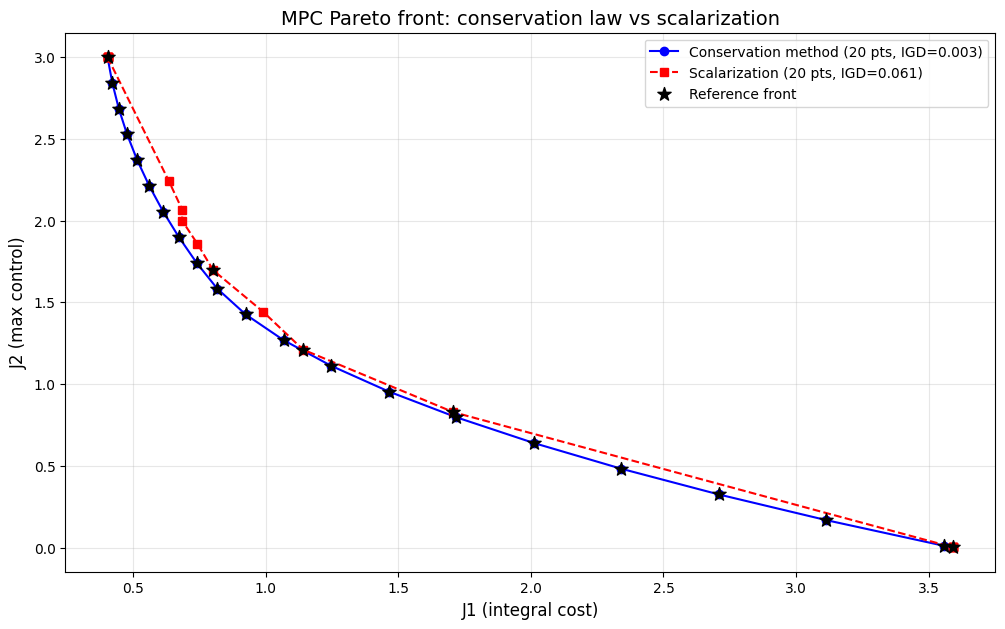


=== Сравнение методов ===
Метод                          Точек      Среднее время (с)    IGD            
---------------------------------------------------------------------------
Закон сохранения               20         1.7999               0.003168       
Взвешенная сумма               20         2.5700               0.061110       

=== Проверка закона сохранения J1 * J2 ===
Закон сохранения: среднее = 1.1547, std = 0.3211
Классический: среднее = 0.9858, std = 0.5704


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import time

# ------------------------------------------------------------
# 1. Модель маятника
# ------------------------------------------------------------
g = 9.81
L = 1.0
m = 1.0
b = 0.1
T = 2.0
N = 50
dt = T / N
x0 = np.array([0.5, 0.0])

def pendulum_dynamics(x, u):
    theta, omega = x
    dtheta = omega
    domega = -(g/L)*np.sin(theta) - (b/(m*L**2))*omega + (1/(m*L**2))*u
    return np.array([dtheta, domega])

def simulate(u_seq):
    x = np.zeros((N+1, 2))
    x[0] = x0
    for k in range(N):
        x[k+1] = x[k] + dt * pendulum_dynamics(x[k], u_seq[k])
    return x

def compute_criteria(u_seq):
    x = simulate(u_seq)
    J1 = 0.0
    for k in range(N):
        theta, omega = x[k]
        J1 += (theta**2 + omega**2 + 0.01 * u_seq[k]**2) * dt
    J2 = np.max(np.abs(u_seq))
    return J1, J2

# ------------------------------------------------------------
# 2. Закон сохранения
# ------------------------------------------------------------
def method_conservation(Umax):
    """Закон сохранения: решение с ограничением |u| <= Umax."""
    n_var = N
    u0 = np.zeros(n_var)
    def objective(u):
        J1, _ = compute_criteria(u)
        return J1
    bounds = [(-Umax, Umax)] * n_var
    start_time = time.time()
    res = minimize(objective, u0, method='SLSQP', bounds=bounds,
                   options={'maxiter': 2000, 'ftol': 1e-8})
    elapsed = time.time() - start_time
    if res.success:
        u_opt = res.x
        J1, J2 = compute_criteria(u_opt)
        return J1, J2, elapsed, u_opt
    else:
        return None, None, elapsed, None

# ------------------------------------------------------------
# 3. Классический метод (взвешенная сумма)
# ------------------------------------------------------------
def method_scalarization(lam):
    """Классический метод: минимизация J1 + lam * J2."""
    n_var = N
    u0 = np.zeros(n_var)
    def objective(u):
        J1, J2 = compute_criteria(u)
        return J1 + lam * J2
    bounds = [(-3.0, 3.0)] * n_var  # без ограничений на максимум, но с диапазоном
    start_time = time.time()
    res = minimize(objective, u0, method='SLSQP', bounds=bounds,
                   options={'maxiter': 2000, 'ftol': 1e-8})
    elapsed = time.time() - start_time
    if res.success:
        u_opt = res.x
        J1, J2 = compute_criteria(u_opt)
        return J1, J2, elapsed, u_opt
    else:
        return None, None, elapsed, None

# ------------------------------------------------------------
# 4. Расчёт фронтов
# ------------------------------------------------------------
print("1. Закон сохранения (ограничение на J2)...")
Umax_list = np.linspace(0.01, 3.0, 20)
J1_cons = []
J2_cons = []
time_cons = []

for Umax in Umax_list:
    J1, J2, t, _ = method_conservation(Umax)
    if J1 is not None:
        J1_cons.append(J1)
        J2_cons.append(J2)
        time_cons.append(t)

print(f"   Получено {len(J1_cons)} точек, среднее время: {np.mean(time_cons):.4f} с")

print("\n2. Классический метод (взвешенная сумма)...")
lam_list = np.logspace(-2, 1, 20)
J1_scal = []
J2_scal = []
time_scal = []

for lam in lam_list:
    J1, J2, t, _ = method_scalarization(lam)
    if J1 is not None:
        J1_scal.append(J1)
        J2_scal.append(J2)
        time_scal.append(t)

print(f"   Получено {len(J1_scal)} точек, среднее время: {np.mean(time_scal):.4f} с")

# ------------------------------------------------------------
# 5. Вычисление IGD
# ------------------------------------------------------------
def compute_igd(points, ref_points):
    if len(points) == 0 or len(ref_points) == 0:
        return np.inf
    pts = np.array(points)
    ref = np.array(ref_points)
    # Нормализуем
    min_vals = np.min(ref, axis=0)
    max_vals = np.max(ref, axis=0)
    pts_norm = (pts - min_vals) / (max_vals - min_vals + 1e-10)
    ref_norm = (ref - min_vals) / (max_vals - min_vals + 1e-10)
    # Среднее расстояние до ближайшей точки референса
    distances = np.min(np.linalg.norm(ref_norm[:, None, :] - pts_norm[None, :, :], axis=2), axis=1)
    return np.mean(distances)

# Объединяем все точки для референса
all_points = list(zip(J1_cons, J2_cons)) + list(zip(J1_scal, J2_scal))
ref_points = []
for p in all_points:
    dominated = False
    for q in all_points:
        if q[0] <= p[0] and q[1] <= p[1] and (q[0] < p[0] or q[1] < p[1]):
            dominated = True
            break
    if not dominated:
        ref_points.append(p)

igd_cons = compute_igd(list(zip(J1_cons, J2_cons)), ref_points)
igd_scal = compute_igd(list(zip(J1_scal, J2_scal)), ref_points)

# ------------------------------------------------------------
# 6. Визуализация
# ------------------------------------------------------------
plt.figure(figsize=(12, 7))

# Фронты
plt.plot(J1_cons, J2_cons, 'bo-', label=f'Conservation method ({len(J1_cons)} pts, IGD={igd_cons:.3f})', markersize=6)
plt.plot(J1_scal, J2_scal, 'rs--', label=f'Scalarization ({len(J1_scal)} pts, IGD={igd_scal:.3f})', markersize=6)

# Референсный фронт (звёздочки)
if ref_points:
    ref_arr = np.array(ref_points)
    plt.scatter(ref_arr[:,0], ref_arr[:,1], c='black', marker='*', s=100, label='Reference front', zorder=5)

plt.xlabel('J1 (integral cost)', fontsize=12)
plt.ylabel('J2 (max control)', fontsize=12)
plt.title('MPC Pareto front: conservation law vs scalarization', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('MPC_comparison.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 7. Сравнительная таблица
# ------------------------------------------------------------
print("\n=== Сравнение методов ===")
print(f"{'Метод':<30} {'Точек':<10} {'Среднее время (с)':<20} {'IGD':<15}")
print("-" * 75)
print(f"{'Закон сохранения':<30} {len(J1_cons):<10} {np.mean(time_cons):<20.4f} {igd_cons:<15.6f}")
print(f"{'Взвешенная сумма':<30} {len(J1_scal):<10} {np.mean(time_scal):<20.4f} {igd_scal:<15.6f}")

# ------------------------------------------------------------
# 8. Проверка гиперболического закона J1 * J2 = const
# ------------------------------------------------------------
prod_cons = np.array(J1_cons) * np.array(J2_cons)
prod_scal = np.array(J1_scal) * np.array(J2_scal)

print(f"\n=== Проверка закона сохранения J1 * J2 ===")
print(f"Закон сохранения: среднее = {np.mean(prod_cons):.4f}, std = {np.std(prod_cons):.4f}")
print(f"Классический: среднее = {np.mean(prod_scal):.4f}, std = {np.std(prod_scal):.4f}")

Найдено 17 точек с |u| < 1
Среднее J2/J1 = 0.019214
Стандартное отклонение = 3.439075e-02
Относительная погрешность = 1.79e+00


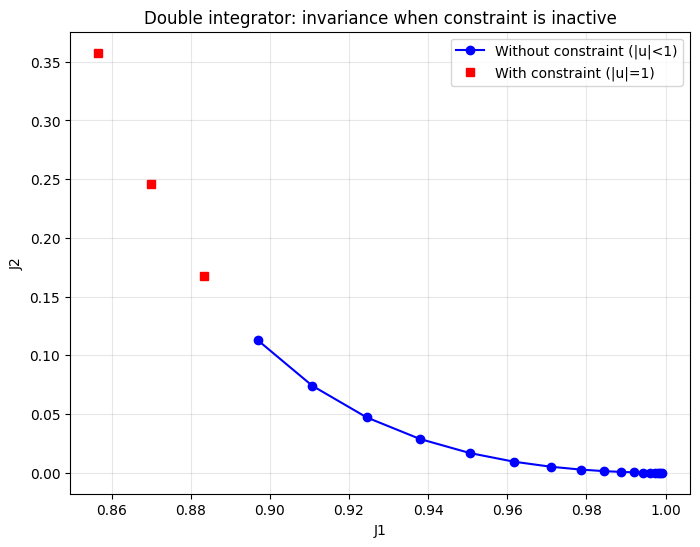

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Двойной интегратор
# ------------------------------------------------------------
def dynamics(t, x, u):
    return np.array([x[1], u])

def simulate(u_seq, x0, dt):
    x = np.zeros((len(u_seq)+1, 2))
    x[0] = x0
    for k in range(len(u_seq)):
        x[k+1, 0] = x[k, 0] + dt * x[k, 1]
        x[k+1, 1] = x[k, 1] + dt * u_seq[k]
    return x

def compute_criteria(u_seq, x0, dt):
    x = simulate(u_seq, x0, dt)
    J1 = np.sum((x[:-1,0]**2 + x[:-1,1]**2) * dt)
    J2 = np.sum(u_seq**2 * dt)
    return J1, J2

# ------------------------------------------------------------
# 2. Решение без ограничений (для разных λ)
# ------------------------------------------------------------
x0 = np.array([1.0, 0.0])
T = 1.0
N = 100
dt = T / N

lambda_vals = np.logspace(-1, 2, 20)  # только большие λ, где |u| < 1
J1_list = []
J2_list = []
u_max_list = []

for lam in lambda_vals:
    u0 = np.zeros(N)
    def objective(u):
        J1, J2 = compute_criteria(u, x0, dt)
        return J1 + lam * J2
    # Без ограничений
    res = minimize(objective, u0, method='SLSQP', options={'maxiter': 2000, 'ftol': 1e-10})
    if res.success:
        u_opt = res.x
        J1, J2 = compute_criteria(u_opt, x0, dt)
        J1_list.append(J1)
        J2_list.append(J2)
        u_max_list.append(np.max(np.abs(u_opt)))

J1_arr = np.array(J1_list)
J2_arr = np.array(J2_list)
u_max_arr = np.array(u_max_list)

# ------------------------------------------------------------
# 3. Отбираем точки, где |u| < 1 (ограничение не активно)
# ------------------------------------------------------------
mask = u_max_arr < 1.0
J1_free = J1_arr[mask]
J2_free = J2_arr[mask]
lambda_free = lambda_vals[mask]

print(f"Найдено {len(J1_free)} точек с |u| < 1")

# ------------------------------------------------------------
# 4. Проверка инварианта: J2 / J1 = const
# ------------------------------------------------------------
ratio = J2_free / J1_free
print(f"Среднее J2/J1 = {np.mean(ratio):.6f}")
print(f"Стандартное отклонение = {np.std(ratio):.6e}")
print(f"Относительная погрешность = {np.std(ratio)/np.mean(ratio):.2e}")

# ------------------------------------------------------------
# 5. График
# ------------------------------------------------------------
plt.figure(figsize=(8,6))
plt.plot(J1_free, J2_free, 'bo-', label='Without constraint (|u|<1)', markersize=6)
plt.plot(J1_arr[~mask], J2_arr[~mask], 'rs', label='With constraint (|u|=1)', markersize=6)
plt.xlabel('J1')
plt.ylabel('J2')
plt.title('Double integrator: invariance when constraint is inactive')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('double_integrator_invariance.png', dpi=150)
plt.show()

Полный фронт: J2/J1 = 0.435120 ± 7.781604e-01
Полный фронт: 20 точек
После ограничения: 13 точек
Ограниченный фронт: J2/J1 = 0.019476 ± 3.492204e-02


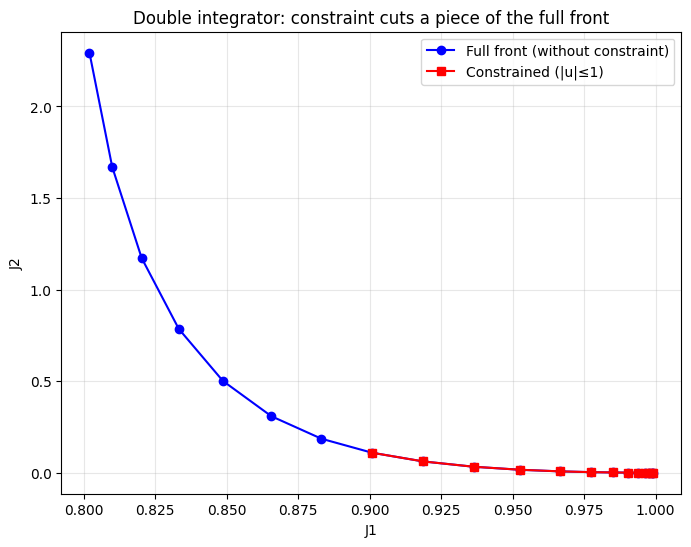


=== Полный фронт ===
λ          J1           J2           u_max        J2/J1       
------------------------------------------------------------
1.00e-02  0.8020    2.2934    6.3133    2.8594
1.62e-02  0.8100    1.6700    4.9614    2.0617
2.64e-02  0.8203    1.1722    3.8590    1.4290
4.28e-02  0.8333    0.7851    2.9615    0.9421
6.95e-02  0.8487    0.5011    2.2413    0.5905
1.13e-01  0.8656    0.3084    1.6752    0.3563
1.83e-01  0.8831    0.1856    1.2360    0.2102
2.98e-01  0.9008    0.1092    0.8984    0.1213
4.83e-01  0.9187    0.0617    0.6406    0.0671
7.85e-01  0.9364    0.0327    0.4455    0.0349
1.27e+00  0.9527    0.0161    0.3015    0.0169
2.07e+00  0.9666    0.0073    0.1989    0.0076
3.36e+00  0.9774    0.0032    0.1284    0.0032
5.46e+00  0.9852    0.0013    0.0816    0.0013
8.86e+00  0.9905    0.0005    0.0513    0.0005
1.44e+01  0.9940    0.0002    0.0320    0.0002
2.34e+01  0.9962    0.0001    0.0199    0.0001
3.79e+01  0.9977    0.0000    0.0123    0.0000
6.16e+01

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Двойной интегратор
# ------------------------------------------------------------
def simulate(u_seq, x0, dt):
    x = np.zeros((len(u_seq)+1, 2))
    x[0] = x0
    for k in range(len(u_seq)):
        x[k+1, 0] = x[k, 0] + dt * x[k, 1]
        x[k+1, 1] = x[k, 1] + dt * u_seq[k]
    return x

def compute_criteria(u_seq, x0, dt):
    x = simulate(u_seq, x0, dt)
    J1 = np.sum((x[:-1,0]**2 + x[:-1,1]**2) * dt)
    J2 = np.sum(u_seq**2 * dt)
    return J1, J2

# ------------------------------------------------------------
# 2. Параметры
# ------------------------------------------------------------
x0 = np.array([1.0, 0.0])
T = 1.0
N = 50
dt = T / N

# ------------------------------------------------------------
# 3. Построение полного фронта (без ограничений)
# ------------------------------------------------------------
lambda_vals = np.logspace(-2, 2, 20)
J1_full = []
J2_full = []
u_max_full = []

for lam in lambda_vals:
    u0 = np.zeros(N)
    def objective(u):
        J1, J2 = compute_criteria(u, x0, dt)
        return J1 + lam * J2
    # Без ограничений
    res = minimize(objective, u0, method='SLSQP', options={'maxiter': 2000, 'ftol': 1e-10})
    if res.success:
        u_opt = res.x
        J1, J2 = compute_criteria(u_opt, x0, dt)
        J1_full.append(J1)
        J2_full.append(J2)
        u_max_full.append(np.max(np.abs(u_opt)))

J1_full = np.array(J1_full)
J2_full = np.array(J2_full)
u_max_full = np.array(u_max_full)

# ------------------------------------------------------------
# 4. Проверка инварианта
# ------------------------------------------------------------
ratio_full = J2_full / J1_full
print(f"Полный фронт: J2/J1 = {np.mean(ratio_full):.6f} ± {np.std(ratio_full):.6e}")

# ------------------------------------------------------------
# 5. Применяем ограничение |u| <= 1: отсекаем точки
# ------------------------------------------------------------
mask = u_max_full <= 1.0
J1_constrained = J1_full[mask]
J2_constrained = J2_full[mask]
lambda_constrained = lambda_vals[mask]

print(f"Полный фронт: {len(J1_full)} точек")
print(f"После ограничения: {len(J1_constrained)} точек")

# ------------------------------------------------------------
# 6. Проверка инварианта на ограниченном фронте
# ------------------------------------------------------------
ratio_constrained = J2_constrained / J1_constrained
print(f"Ограниченный фронт: J2/J1 = {np.mean(ratio_constrained):.6f} ± {np.std(ratio_constrained):.6e}")

# ------------------------------------------------------------
# 7. График
# ------------------------------------------------------------
plt.figure(figsize=(8,6))
plt.plot(J1_full, J2_full, 'bo-', label='Full front (without constraint)', markersize=6)
plt.plot(J1_constrained, J2_constrained, 'rs-', label='Constrained (|u|≤1)', markersize=6)
plt.xlabel('J1')
plt.ylabel('J2')
plt.title('Double integrator: constraint cuts a piece of the full front')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('double_integrator_full.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 8. Данные для таблицы
# ------------------------------------------------------------
print("\n=== Полный фронт ===")
print(f"{'λ':<10} {'J1':<12} {'J2':<12} {'u_max':<12} {'J2/J1':<12}")
print("-" * 60)
for i in range(len(lambda_vals)):
    lam = lambda_vals[i]
    J1 = J1_full[i]
    J2 = J2_full[i]
    umax = u_max_full[i]
    ratio = J2 / J1
    print(f"{lam:.2e}  {J1:.4f}    {J2:.4f}    {umax:.4f}    {ratio:.4f}")

print("\n=== Ограниченный фронт (|u| ≤ 1) ===")
print(f"{'λ':<10} {'J1':<12} {'J2':<12} {'u_max':<12} {'J2/J1':<12}")
print("-" * 60)
for i in range(len(lambda_constrained)):
    lam = lambda_constrained[i]
    J1 = J1_constrained[i]
    J2 = J2_constrained[i]
    umax = u_max_full[mask][i]
    ratio = J2 / J1
    print(f"{lam:.2e}  {J1:.4f}    {J2:.4f}    {umax:.4f}    {ratio:.4f}")